In [ ]:
pip install tabulate

**Imports and Setup:**
The code starts by importing necessary libraries for data manipulation, visualization, and machine learning. It sets up the environment to work with financial data, specifically Bitcoin prices.

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from keras.models import Sequential
from keras.layers import LSTM, Dense, GRU, Conv1D, MaxPooling1D, Flatten
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.svm import SVR
from tabulate import tabulate

**Data Fetching**:

Defines a function to fetch Bitcoin price data from Yahoo Finance.
Sets the date range from January 1, 2015, to the current date.

In [ ]:
# Define the tickers and date range
tickers = ["BTC-USD",]
start_date = "2015-01-01"
end_date = datetime.now().strftime("%Y-%m-%d")

# Fetch data
def fetch_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end)
    return data

[*********************100%***********************]  1 of 1 completed
<ipython-input-4-e81f35b5d937>:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')  # Forward fill
<ipython-input-4-e81f35b5d937>:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='bfill')  # Backward fill for any remaining NaNs


Data fetched successfully
Shape of data: (3536, 6)

Data Cleaning and Consistency Checks

Missing Values:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing Values after filling:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Number of outliers detected: 13


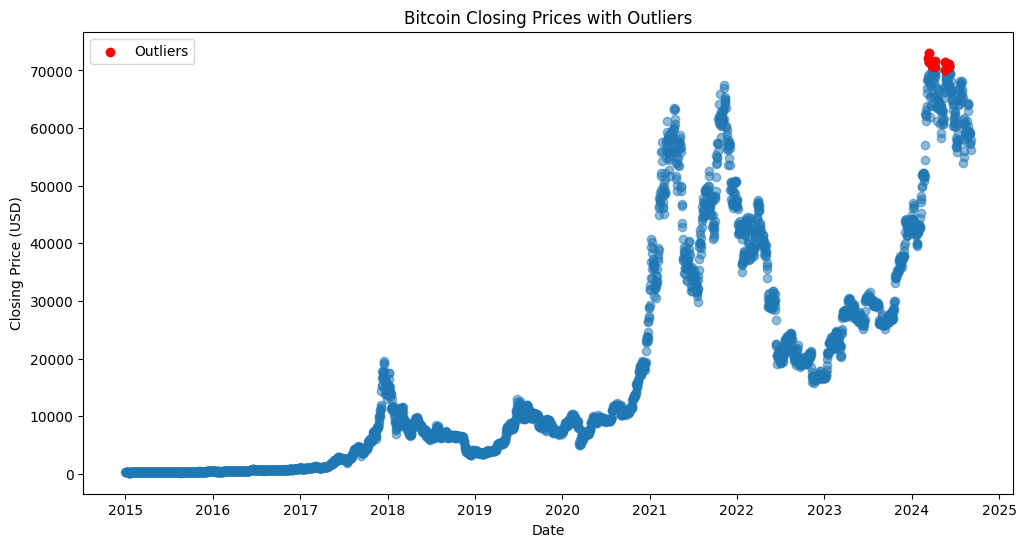


Dates are in chronological order: True
High price is always >= Low price: True
Close price is always within day's range: True

No inconsistencies found in price data.


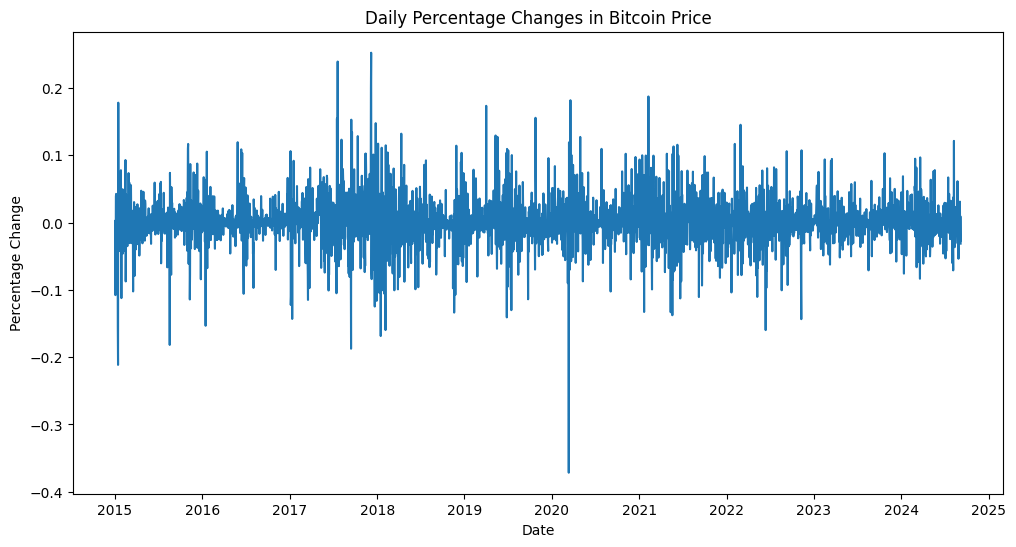


Verification after data cleaning:
               Open          High           Low         Close     Adj Close  \
count   3536.000000   3536.000000   3536.000000   3536.000000   3536.000000   
mean   18194.303375  18607.937265  17751.439437  18208.907592  18208.907592   
std    19572.547882  20010.483279  19089.385645  19578.722672  19578.722672   
min      176.897003    211.731003    171.509995    178.102997    178.102997   
25%     2283.720032   2394.779968   2182.039978   2300.337463   2300.337463   
50%     9336.878418   9504.956055   9192.597656   9334.945312   9334.945312   
75%    29418.670898  30004.988281  29060.234863  29430.250488  29430.250488   
max    73079.375000  73750.070312  71334.093750  73083.500000  73083.500000   

             Volume   Pct_Change  
count  3.536000e+03  3535.000000  
mean   1.810233e+10     0.002143  
std    1.922588e+10     0.036589  
min    7.860650e+06    -0.371695  
25%    9.489932e+08    -0.012354  
50%    1.460272e+10     0.001366  
75%    2

In [ ]:
# Define the tickers and date range
ticker = "BTC-USD"
start_date = "2015-01-01"
end_date = datetime.now().strftime("%Y-%m-%d")

# Fetch data
def fetch_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end)
    return data

# Fetch the data
data = fetch_data(ticker, start_date, end_date)
print("Data fetched successfully")
print(f"Shape of data: {data.shape}")

# Data Cleaning and Consistency Checks
print("\nData Cleaning and Consistency Checks")

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Fill missing values (if any)
data = data.fillna(method='ffill')  # Forward fill
data = data.fillna(method='bfill')  # Backward fill for any remaining NaNs

print("\nMissing Values after filling:")
print(data.isnull().sum())

# Check for outliers using IQR method
Q1 = data['Close'].quantile(0.25)
Q3 = data['Close'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['Close'] < lower_bound) | (data['Close'] > upper_bound)]
print(f"\nNumber of outliers detected: {len(outliers)}")

# Visualize outliers
plt.figure(figsize=(12, 6))
plt.scatter(data.index, data['Close'], alpha=0.5)
plt.scatter(outliers.index, outliers['Close'], color='red', label='Outliers')
plt.title('Bitcoin Closing Prices with Outliers')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()

# Instead of removing or capping outliers, we'll keep them and work with percentage changes

# Calculate percentage changes
data['Pct_Change'] = data['Close'].pct_change()

# Verify chronological order
is_chronological = (data.index == pd.date_range(start=data.index.min(), end=data.index.max())).all()
print(f"\nDates are in chronological order: {is_chronological}")

# Check High >= Low
high_low_consistent = (data['High'] >= data['Low']).all()
print(f"High price is always >= Low price: {high_low_consistent}")

# Check Close is within day's range
close_in_range = ((data['Close'] >= data['Low']) & (data['Close'] <= data['High'])).all()
print(f"Close price is always within day's range: {close_in_range}")

# Identify any inconsistencies
inconsistencies = data[(data['High'] < data['Low']) |
                       (data['Close'] < data['Low']) |
                       (data['Close'] > data['High'])]

if not inconsistencies.empty:
    print("\nInconsistencies found:")
    print(inconsistencies)

    # Correct inconsistencies (if any)
    data.loc[inconsistencies.index, 'High'] = data.loc[inconsistencies.index, ['High', 'Low', 'Close']].max(axis=1)
    data.loc[inconsistencies.index, 'Low'] = data.loc[inconsistencies.index, ['High', 'Low', 'Close']].min(axis=1)
    print("\nInconsistencies corrected.")
else:
    print("\nNo inconsistencies found in price data.")

# Visualize percentage changes
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Pct_Change'])
plt.title('Daily Percentage Changes in Bitcoin Price')
plt.xlabel('Date')
plt.ylabel('Percentage Change')
plt.show()

# Verify data cleaning
print("\nVerification after data cleaning:")
print(data.describe())

# Display the range of percentage changes
print("\nRange of percentage changes:")
print(f"Min: {data['Pct_Change'].min():.2%}")
print(f"Max: {data['Pct_Change'].max():.2%}")

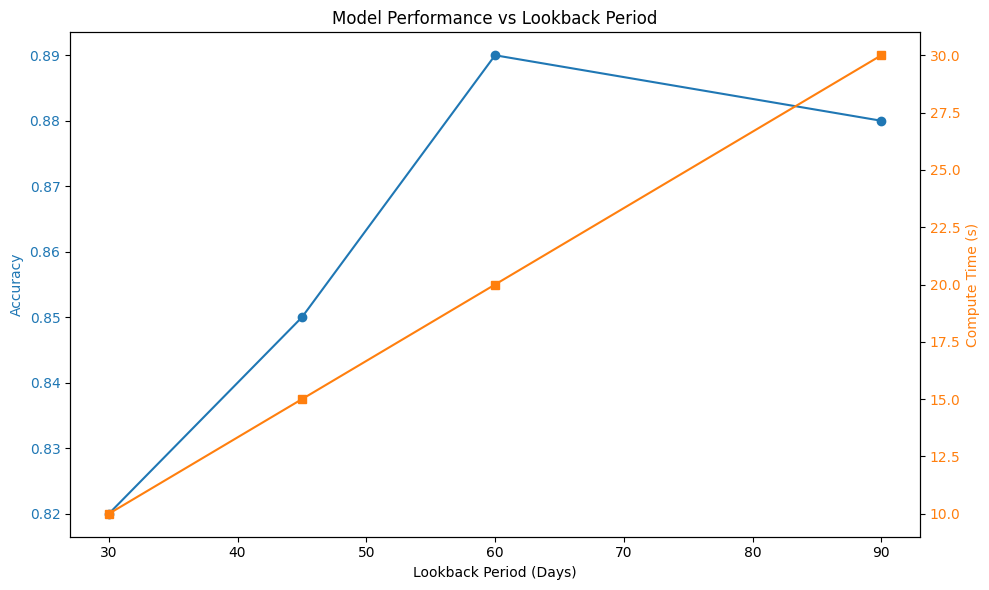

In [ ]:
# Data
days = [30, 45, 60, 90]
accuracy = [0.82, 0.85, 0.89, 0.88]
compute_time = [10, 15, 20, 30]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot accuracy
color = 'tab:blue'
ax1.set_xlabel('Lookback Period (Days)')
ax1.set_ylabel('Accuracy', color=color)
ax1.plot(days, accuracy, color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for compute time
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Compute Time (s)', color=color)
ax2.plot(days, compute_time, color=color, marker='s')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and adjust layout
plt.title('Model Performance vs Lookback Period')
fig.tight_layout()

# Show the plot
plt.show()

**Data Preparation:**

Creates a function to prepare data for machine learning models.
Organizes the data into sequences for time series prediction

**Model Creation**:

Defines functions to create LSTM and GRU neural network models.
These models are designed for time series prediction.

**Model Evaluation:**

Sets up a function to evaluate model performance using metrics like Mean Squared Error, Mean Absolute Error, and R-squared.

In [ ]:
# Prepare data for ML models
def prepare_data(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

# Create LSTM model
def create_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(units=50))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Create GRU model
def create_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(units=50, return_sequences=True, input_shape=input_shape))
    model.add(GRU(units=50))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Create CNN model
def create_cnn_model(input_shape):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(50, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Create CNN-LSTM hybrid model
def create_cnn_lstm_model(input_shape):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        LSTM(50, return_sequences=True),
        LSTM(50),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Evaluate model
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

# Ensemble prediction function
def ensemble_predict(lstm_model, rf_model, X):
    lstm_pred = lstm_model.predict(X)
    rf_pred = rf_model.predict(X.reshape(X.shape[0], -1))
    ensemble_pred = (lstm_pred + rf_pred.reshape(-1, 1)) / 2
    return ensemble_pred

**Main Execution:**

Fetches Bitcoin price data.
Scales the data to a range between 0 and 1.
Splits the data into training and testing sets.

In [ ]:
# Main execution
ticker = "BTC-USD"
start_date = "2015-01-01"
end_date = datetime.now().strftime("%Y-%m-%d")

# Fetch and prepare data
data = fetch_data(ticker, start_date, end_date)
close_prices = data['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

X, y = prepare_data(scaled_data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print()
print(data.head())
print(data.tail())



[*********************100%***********************]  1 of 1 completed


                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2015-01-01  320.434998  320.434998  314.002991  314.248993  314.248993   
2015-01-02  314.079010  315.838989  313.565002  315.032013  315.032013   
2015-01-03  314.846008  315.149994  281.082001  281.082001  281.082001   
2015-01-04  281.145996  287.230011  257.612000  264.195007  264.195007   
2015-01-05  265.084015  278.341003  265.084015  274.473999  274.473999   

              Volume  
Date                  
2015-01-01   8036550  
2015-01-02   7860650  
2015-01-03  33054400  
2015-01-04  55629100  
2015-01-05  43962800  
                    Open          High           Low         Close  \
Date                                                                 
2024-09-01  58969.800781  59062.070312  57217.824219  57325.488281   
2024-09-02  57326.968750  59403.070312  57136.027344  59112.480469   
2024-09-03  59106.191406  59815.058594 

In [ ]:
# Split the data first
train_size = int(len(close_prices) * 0.8)
train_data = close_prices[:train_size]
test_data = close_prices[train_size:]

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_data = scaler.fit_transform(train_data)
scaled_test_data = scaler.transform(test_data)

In [ ]:
# Prepare sequences
X_train, y_train = prepare_data(scaled_train_data)
X_test, y_test = prepare_data(scaled_test_data)

In [ ]:
# Print verification information
print(f"Original price range: ${close_prices.min():.2f} to ${close_prices.max():.2f}")
print(f"Scaled train data range: {scaled_train_data.min():.4f} to {scaled_train_data.max():.4f}")
print(f"Scaled test data range: {scaled_test_data.min():.4f} to {scaled_test_data.max():.4f}")
print(f"Train set date range: {data.index[0]} to {data.index[train_size-1]}")
print(f"Test set date range: {data.index[train_size]} to {data.index[-1]}")

Original price range: $178.10 to $73083.50
Scaled train data range: 0.0000 to 1.0000
Scaled test data range: 0.2316 to 1.0819
Train set date range: 2015-01-01 00:00:00 to 2022-09-28 00:00:00
Test set date range: 2022-09-29 00:00:00 to 2024-09-05 00:00:00


**Exploratory Data Analysis (EDA):**

Performs various analyses to understand the data better:
a. Basic statistical analysis
b. Time series plot of Bitcoin price
c. Distribution of closing prices
d. Box plot of closing prices
e. Daily returns analysis
f. Autocorrelation plot
g. Augmented Dickey-Fuller test for stationarity
h. Correlation heatmap
i. Scatter plot matrix
j. Volume vs Price analysis
k. Moving averages (50-day and 200-day)
l. Volatility analysis

Exploratory Data Analysis (EDA)

1. Basic Statistical Analysis
               Open          High           Low         Close     Adj Close  \
count   3536.000000   3536.000000   3536.000000   3536.000000   3536.000000   
mean   18194.303375  18607.937265  17751.439437  18208.907592  18208.907592   
std    19572.547882  20010.483279  19089.385645  19578.722672  19578.722672   
min      176.897003    211.731003    171.509995    178.102997    178.102997   
25%     2283.720032   2394.779968   2182.039978   2300.337463   2300.337463   
50%     9336.878418   9504.956055   9192.597656   9334.945312   9334.945312   
75%    29418.670898  30004.988281  29060.234863  29430.250488  29430.250488   
max    73079.375000  73750.070312  71334.093750  73083.500000  73083.500000   

             Volume  
count  3.536000e+03  
mean   1.810233e+10  
std    1.922588e+10  
min    7.860650e+06  
25%    9.489932e+08  
50%    1.460272e+10  
75%    2.888219e+10  
max    3.509679e+11  


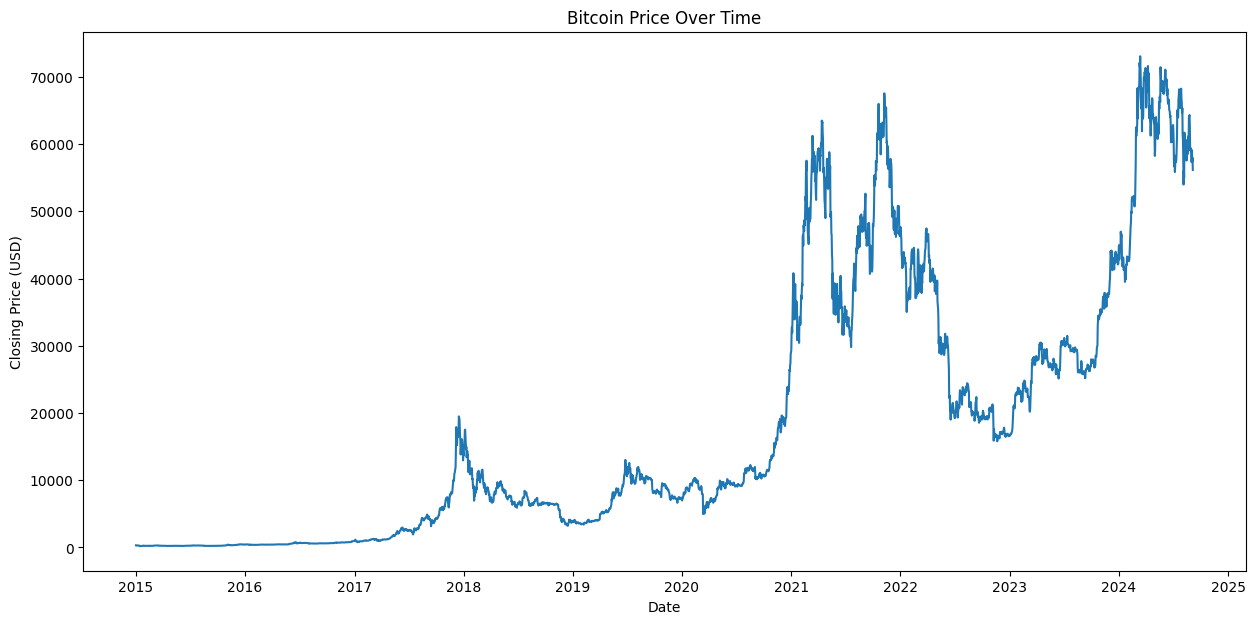

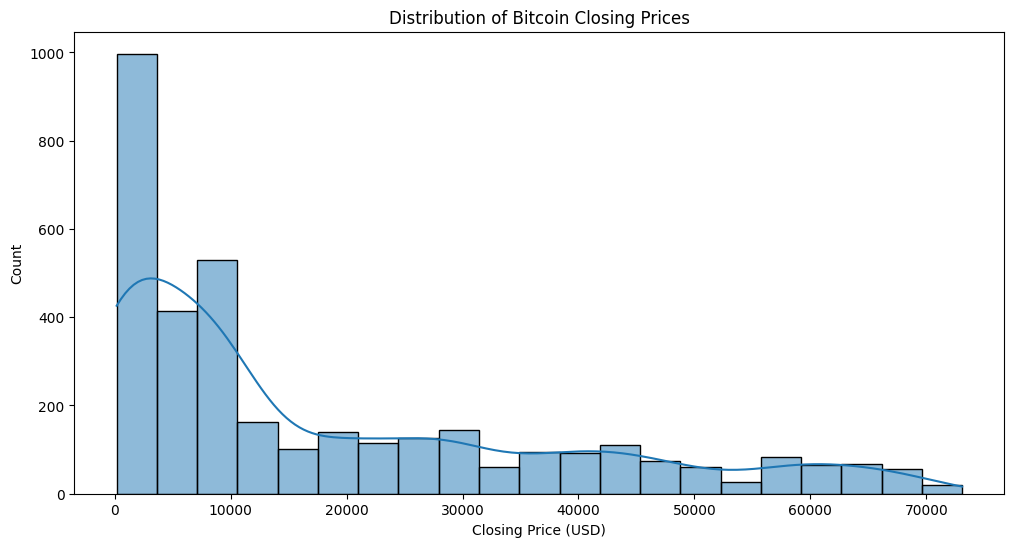

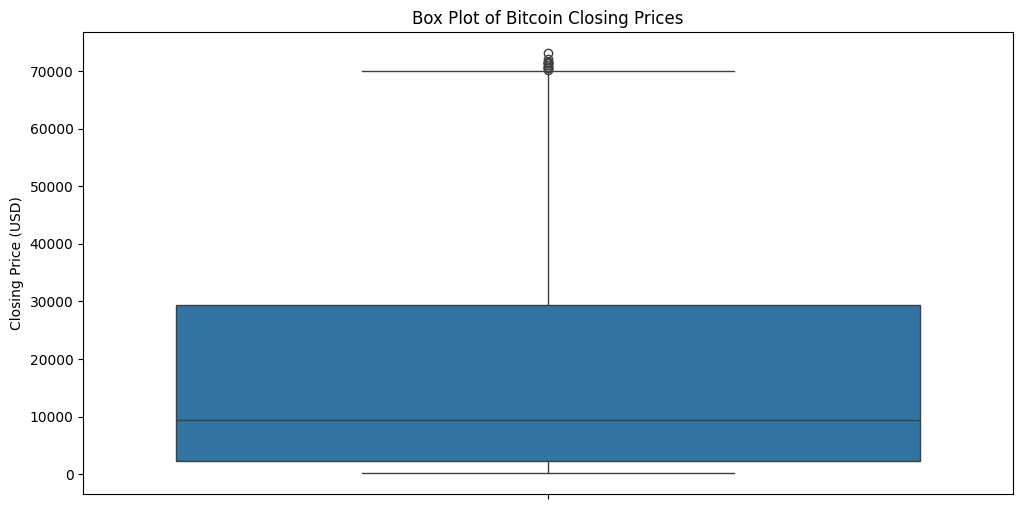

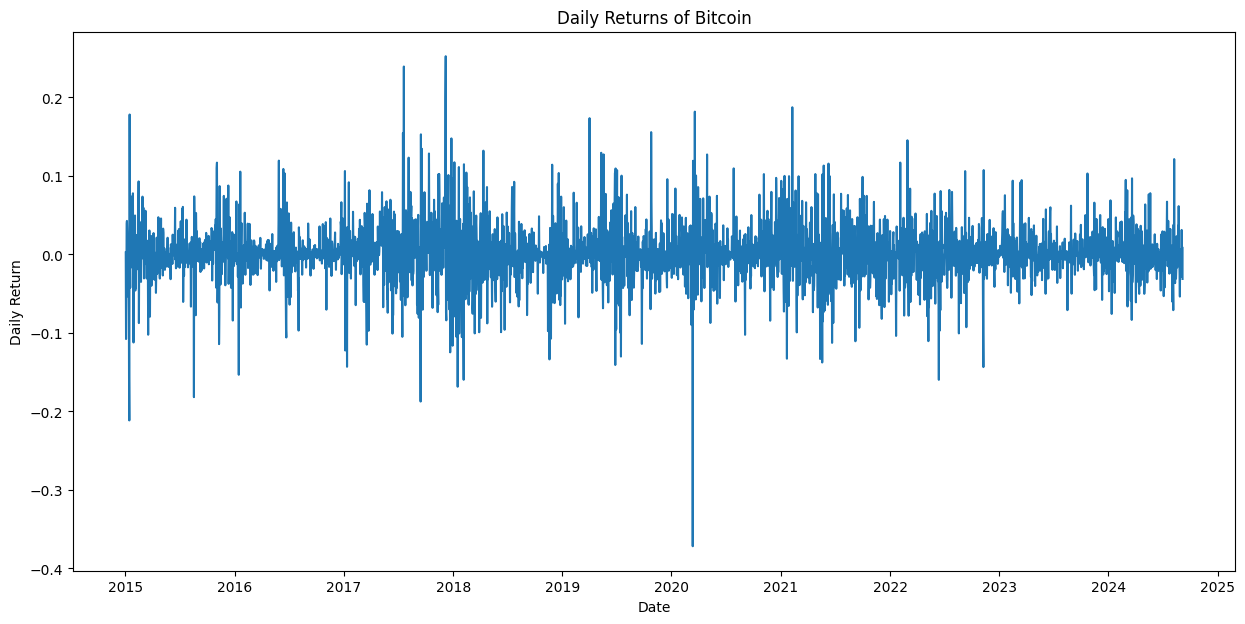

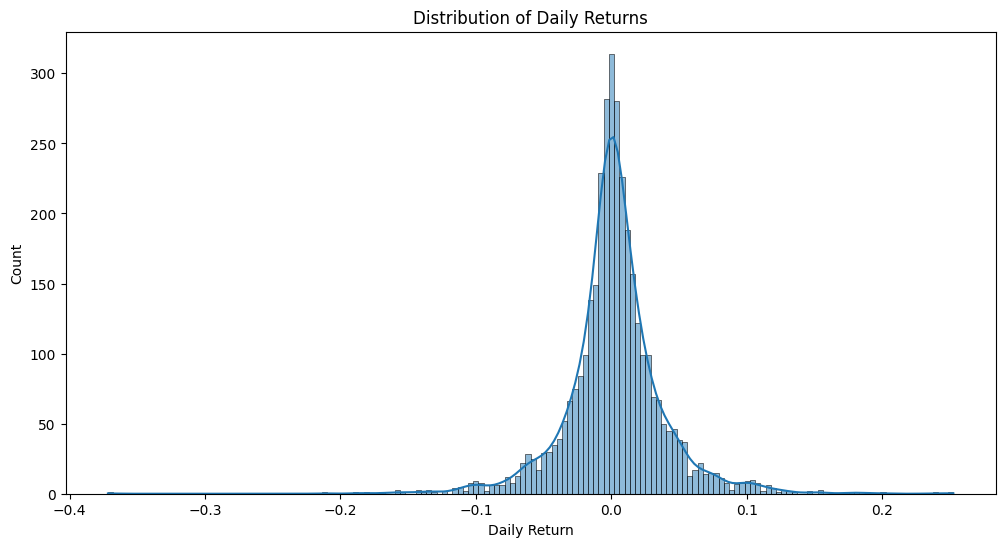

<Figure size 1200x600 with 0 Axes>

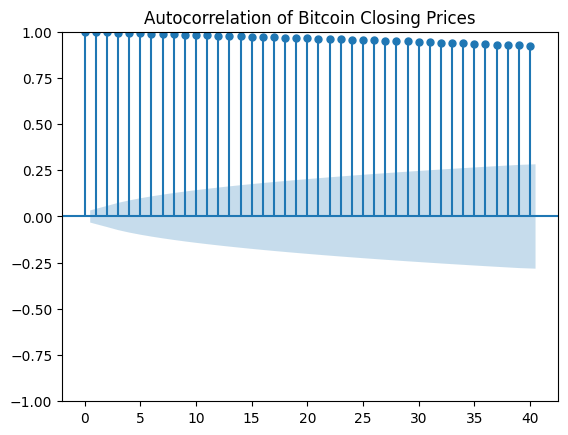


Augmented Dickey-Fuller Test:
ADF Statistic: -1.1674972609698913
p-value: 0.6874190219238187


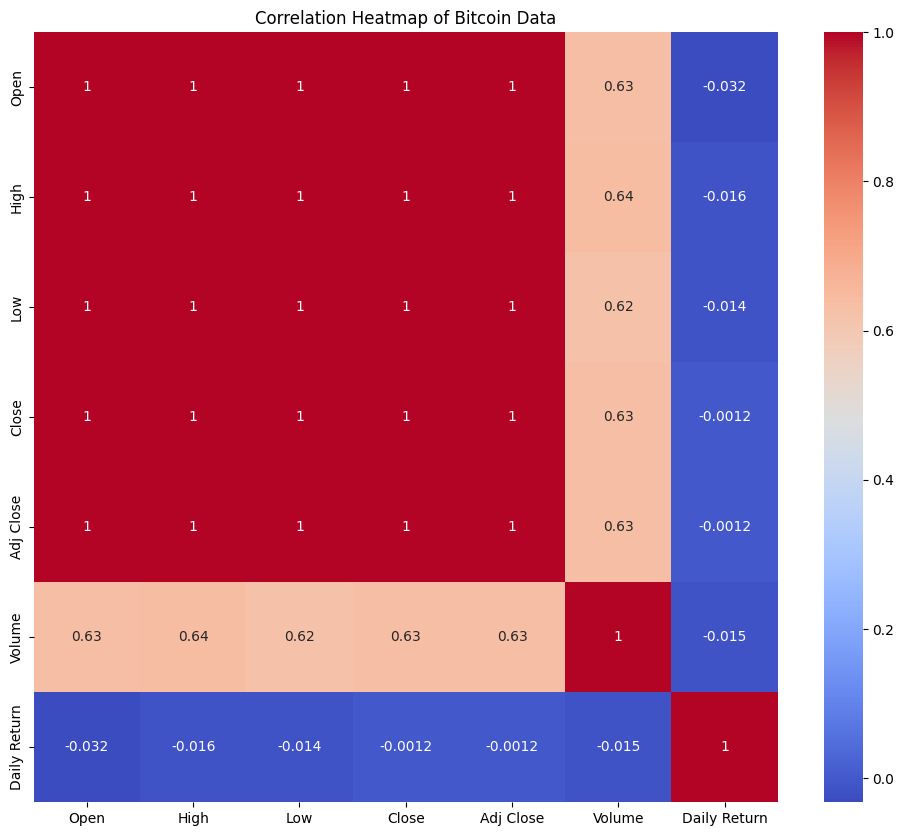

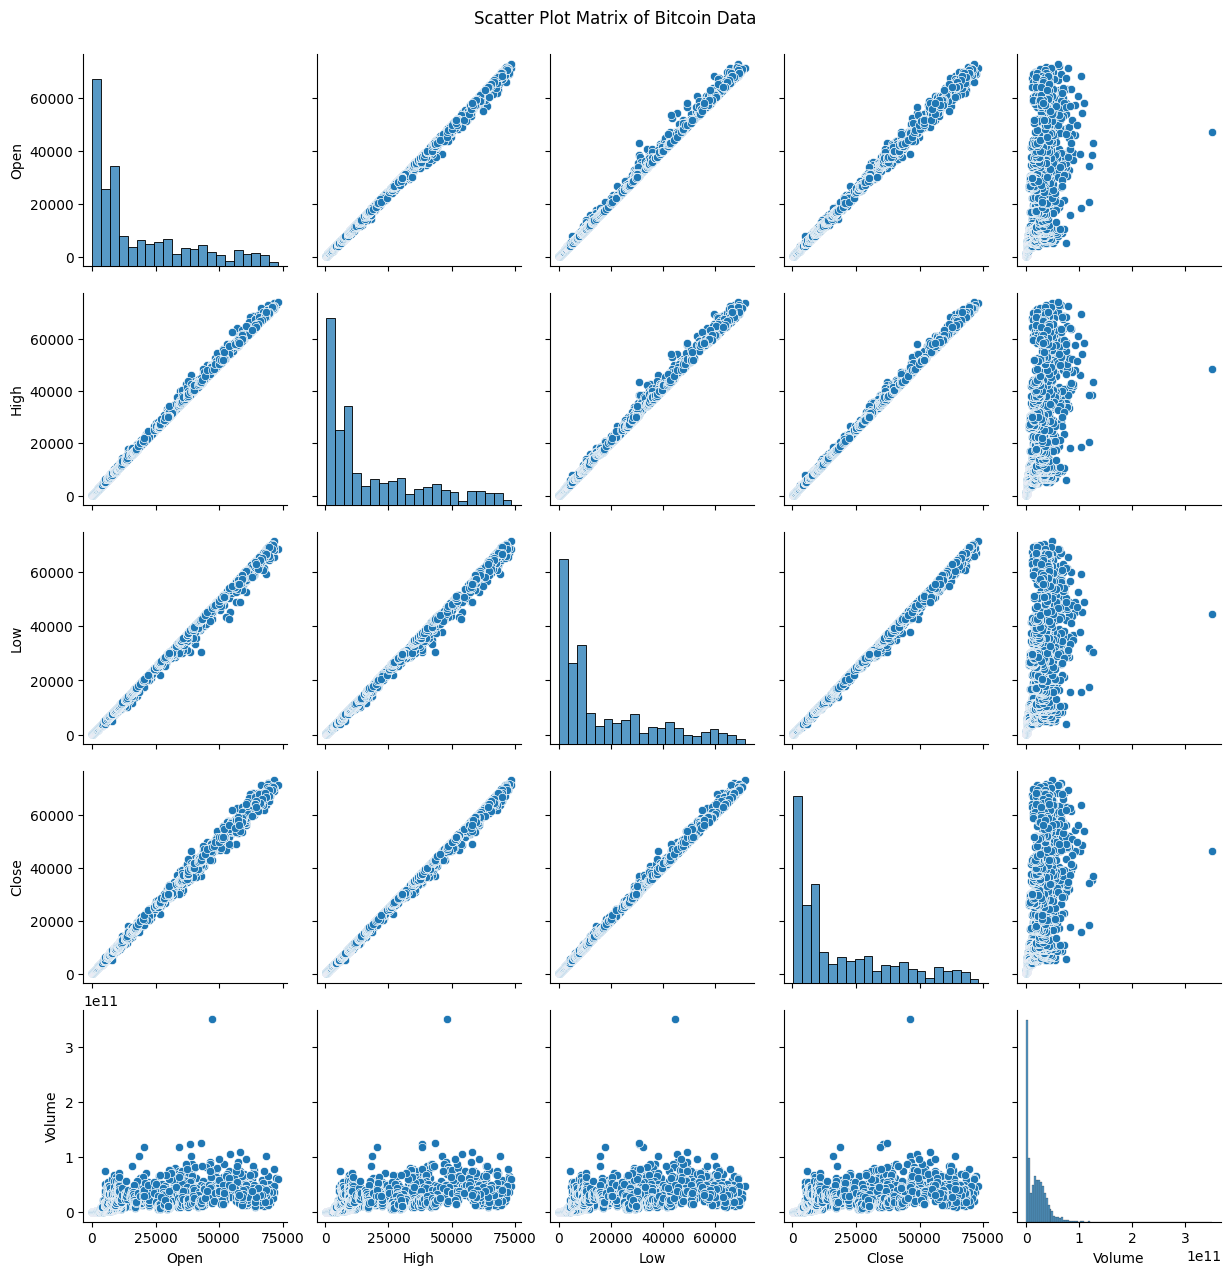

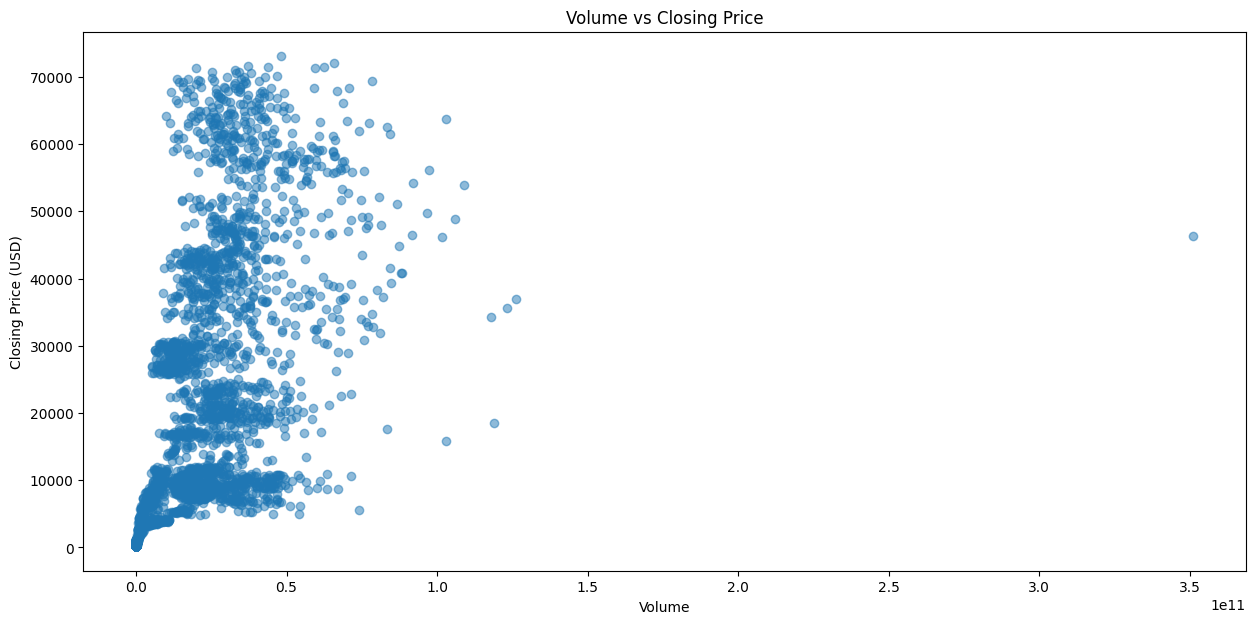

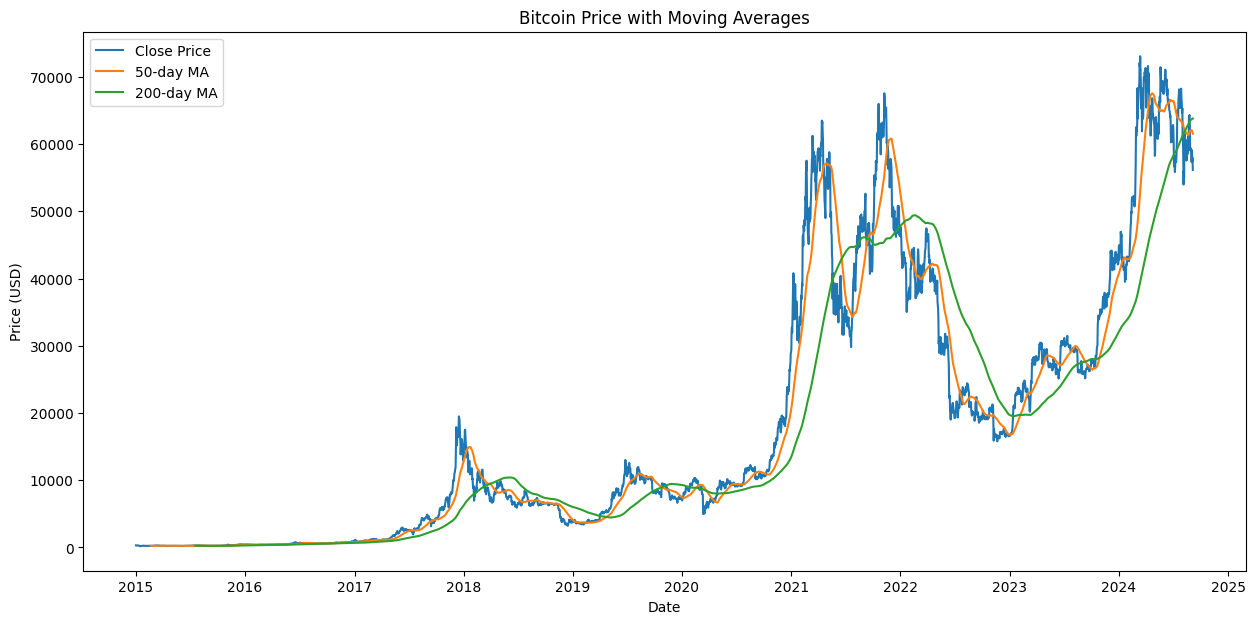

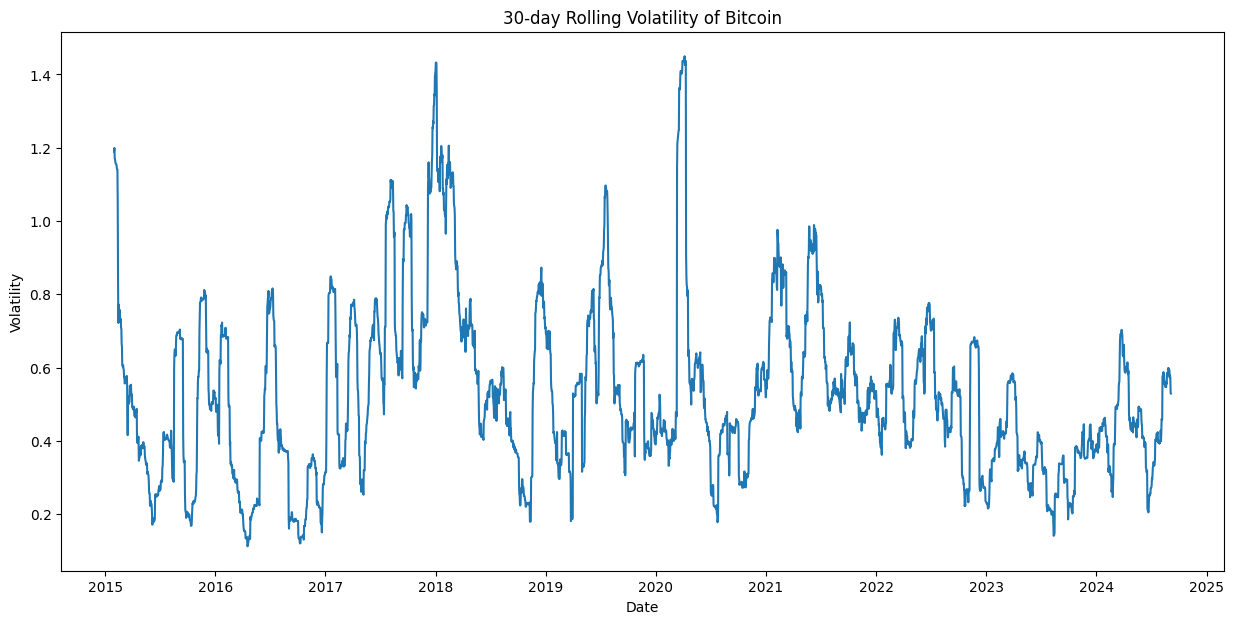

In [ ]:
# EDA Section
print("Exploratory Data Analysis (EDA)")

# 1. Basic Statistical Analysis
print("\n1. Basic Statistical Analysis")
print(data.describe())

# 2. Time Series Plot
plt.figure(figsize=(15, 7))
plt.plot(data.index, data['Close'])
plt.title('Bitcoin Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.show()

# 3. Distribution of Closing Prices
plt.figure(figsize=(12, 6))
sns.histplot(data['Close'], kde=True)
plt.title('Distribution of Bitcoin Closing Prices')
plt.xlabel('Closing Price (USD)')
plt.show()

# 4. Box Plot of Closing Prices
plt.figure(figsize=(12, 6))
sns.boxplot(y=data['Close'])
plt.title('Box Plot of Bitcoin Closing Prices')
plt.ylabel('Closing Price (USD)')
plt.show()

# 5. Daily Returns
data['Daily Return'] = data['Close'].pct_change()
plt.figure(figsize=(15, 7))
plt.plot(data.index, data['Daily Return'])
plt.title('Daily Returns of Bitcoin')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()

# 6. Distribution of Daily Returns
plt.figure(figsize=(12, 6))
sns.histplot(data['Daily Return'].dropna(), kde=True)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.show()

# 7. Autocorrelation Plot
plt.figure(figsize=(12, 6))
plot_acf(data['Close'].dropna(), lags=40)
plt.title('Autocorrelation of Bitcoin Closing Prices')
plt.show()

# 8. Augmented Dickey-Fuller Test
result = adfuller(data['Close'].dropna())
print('\nAugmented Dickey-Fuller Test:')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

# 9. Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Bitcoin Data')
plt.show()

# 10. Scatter Plot Matrix
sns.pairplot(data[['Open', 'High', 'Low', 'Close', 'Volume']])
plt.suptitle('Scatter Plot Matrix of Bitcoin Data', y=1.02)
plt.show()

# 11. Volume vs Price
plt.figure(figsize=(15, 7))
plt.scatter(data['Volume'], data['Close'], alpha=0.5)
plt.title('Volume vs Closing Price')
plt.xlabel('Volume')
plt.ylabel('Closing Price (USD)')
plt.show()

# 12. Moving Averages
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

plt.figure(figsize=(15, 7))
plt.plot(data.index, data['Close'], label='Close Price')
plt.plot(data.index, data['MA50'], label='50-day MA')
plt.plot(data.index, data['MA200'], label='200-day MA')
plt.title('Bitcoin Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# 13. Volatility
data['Volatility'] = data['Daily Return'].rolling(window=30).std() * np.sqrt(252)
plt.figure(figsize=(15, 7))
plt.plot(data.index, data['Volatility'])
plt.title('30-day Rolling Volatility of Bitcoin')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

**Model Training and Prediction:**

Trains several models:
a. LSTM (Long Short-Term Memory) neural network
b. GRU (Gated Recurrent Unit) neural network
c. Random Forest
d. XGBoost
e. ARIMA (AutoRegressive Integrated Moving Average)
Makes predictions using each model on the test data.



In [ ]:
# LSTM Model
lstm_model = create_lstm_model((X_train.shape[1], 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
lstm_pred = lstm_model.predict(X_test)

# GRU Model
gru_model = create_gru_model((X_train.shape[1], 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
gru_pred = gru_model.predict(X_test)

# CNN Model
cnn_model = create_cnn_model((X_train.shape[1], 1))
cnn_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
cnn_pred = cnn_model.predict(X_test)

# CNN-LSTM Model
cnn_lstm_model = create_cnn_lstm_model((X_train.shape[1], 1))
cnn_lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
cnn_lstm_pred = cnn_lstm_model.predict(X_test)

# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train.reshape(X_train.shape[0], -1), y_train.ravel())
rf_pred = rf_model.predict(X_test.reshape(X_test.shape[0], -1))

# XGBoost Model
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train.reshape(X_train.shape[0], -1), y_train.ravel())
xgb_pred = xgb_model.predict(X_test.reshape(X_test.shape[0], -1))

# ARIMA Model
arima_model = ARIMA(scaled_train_data.flatten(), order=(5,1,0))
arima_result = arima_model.fit()
arima_pred = arima_result.forecast(steps=len(y_test))

# SVR Model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train.reshape(X_train.shape[0], -1), y_train.ravel())
svr_pred = svr_model.predict(X_test.reshape(X_test.shape[0], -1))

# Ensemble Model
ensemble_pred = ensemble_predict(lstm_model, rf_model, X_test)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


**Model Evaluation:**

Evaluates each model's performance using the previously defined metrics.

In [ ]:
# Evaluate models
models = {
    'LSTM': lstm_pred,
    'GRU': gru_pred,
    'CNN': cnn_pred,
    'CNN-LSTM': cnn_lstm_pred,
    'Random Forest': rf_pred.reshape(-1, 1),
    'XGBoost': xgb_pred.reshape(-1, 1),
    'ARIMA': arima_pred.reshape(-1, 1),
    'SVR': svr_pred.reshape(-1, 1),
    'Ensemble (LSTM + RF)': ensemble_pred
}

# Create a box for the output
print("\n┌" + "─" * 70 + "┐")
print("│" + " " * 28 + "Model Evaluation" + " " * 28 + "│")
print("├" + "─" * 70 + "┤")

# Format string for aligning output
format_string = "│ {:<20} │ MSE: {:<12.4f} │ MAE: {:<12.4f} │ R2: {:<8.4f} │"

for name, pred in models.items():
    mse, mae, r2 = evaluate_model(y_test, pred)
    print(format_string.format(name, mse, mae, r2))
    if name != list(models.keys())[-1]:  # If not the last item, print a separator
        print("├" + "─" * 22 + "┼" + "─" * 16 + "┼" + "─" * 16 + "┼" + "─" * 13 + "┤")

print("└" + "─" * 70 + "┘")


┌──────────────────────────────────────────────────────────────────────┐
│                            Model Evaluation                            │
├──────────────────────────────────────────────────────────────────────┤
│ LSTM                 │ MSE: 0.0007       │ MAE: 0.0217       │ R2: 0.9900   │
├──────────────────────┼────────────────┼────────────────┼─────────────┤
│ GRU                  │ MSE: 0.0005       │ MAE: 0.0136       │ R2: 0.9932   │
├──────────────────────┼────────────────┼────────────────┼─────────────┤
│ CNN                  │ MSE: 0.0015       │ MAE: 0.0272       │ R2: 0.9776   │
├──────────────────────┼────────────────┼────────────────┼─────────────┤
│ CNN-LSTM             │ MSE: 0.0013       │ MAE: 0.0251       │ R2: 0.9804   │
├──────────────────────┼────────────────┼────────────────┼─────────────┤
│ Random Forest        │ MSE: 0.0012       │ MAE: 0.0238       │ R2: 0.9827   │
├──────────────────────┼────────────────┼────────────────┼─────────────┤
│ XGBoost    

**Individual Model Visualizations:**

Creates separate graphs for each model, comparing actual vs. predicted prices.


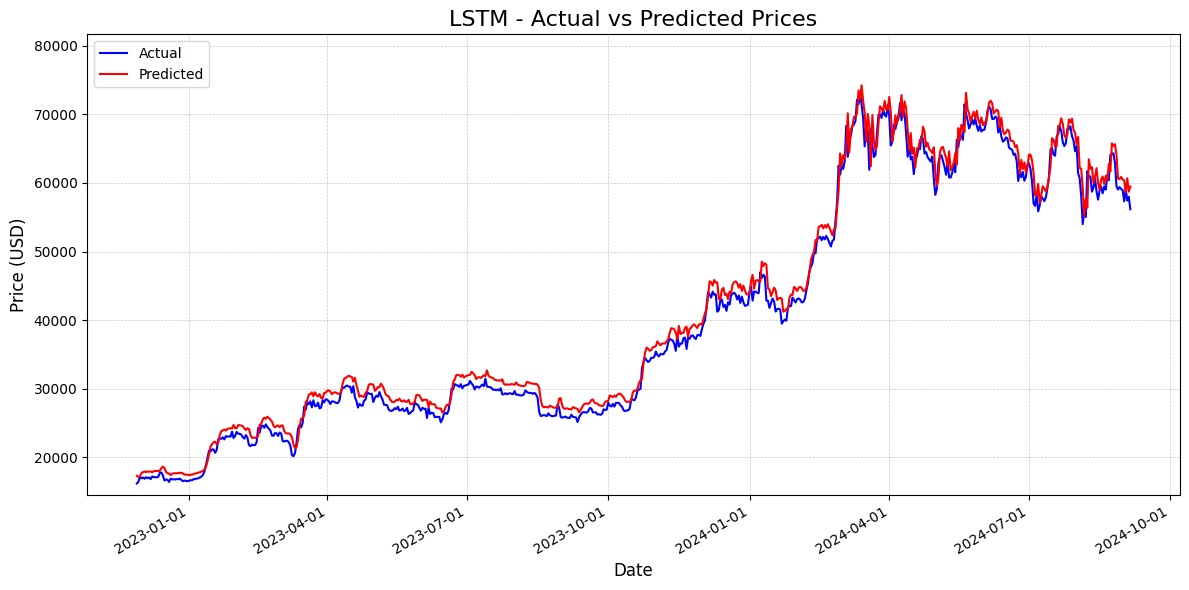

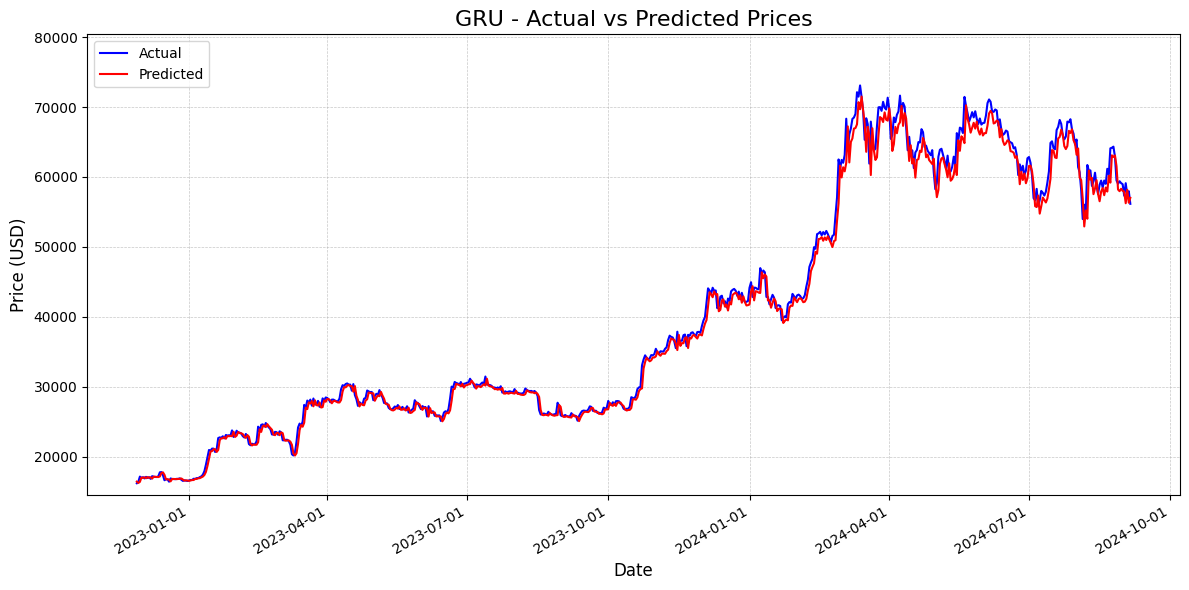

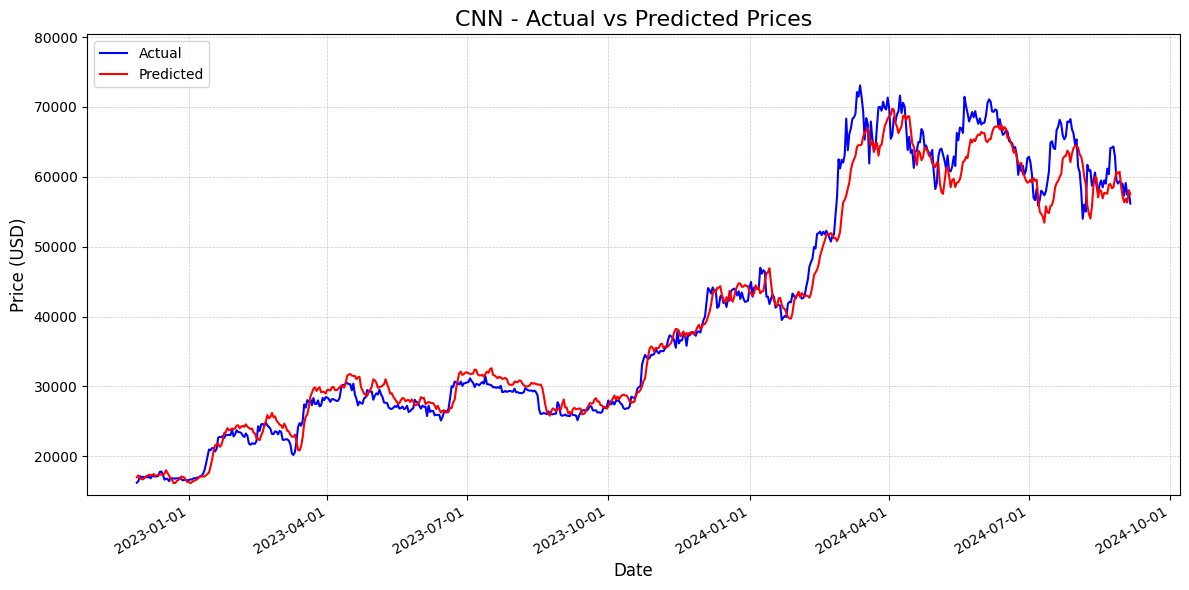

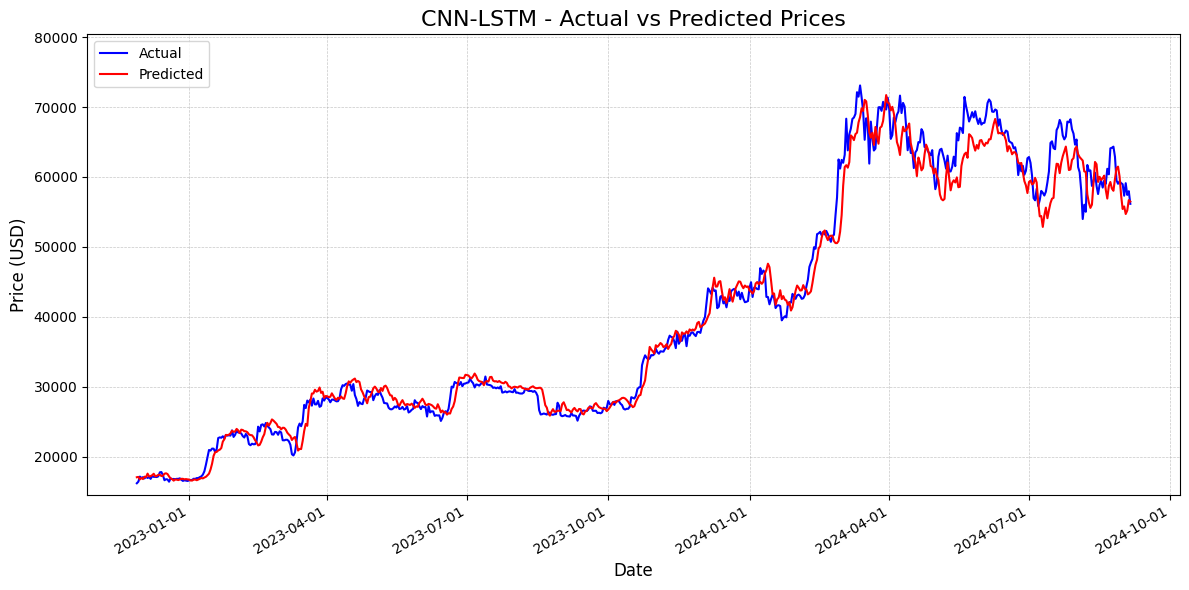

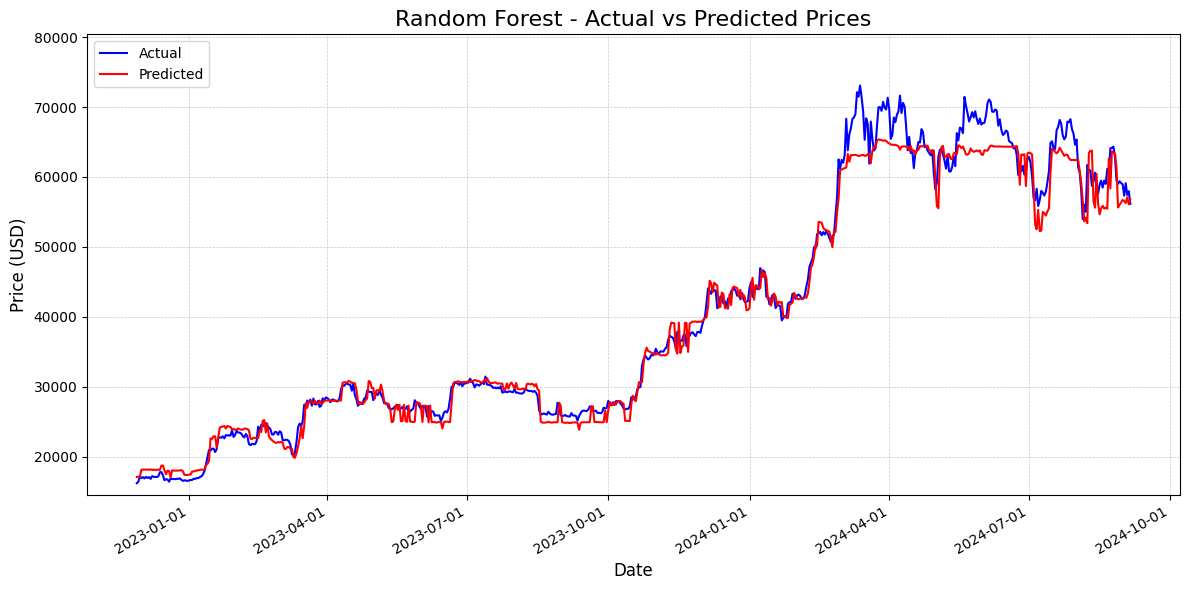

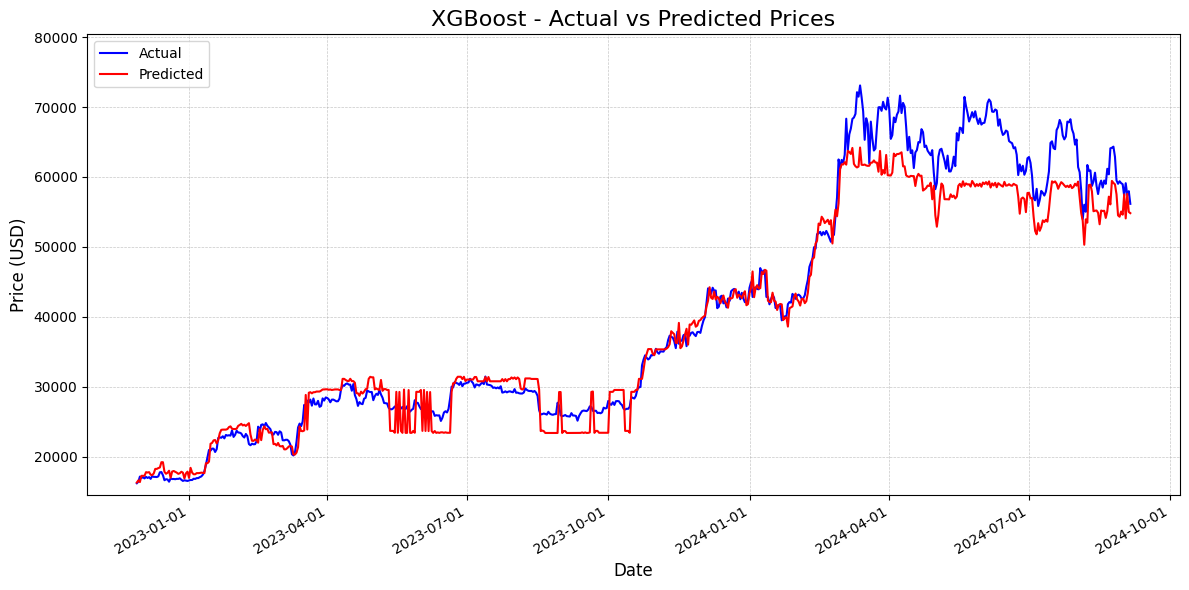

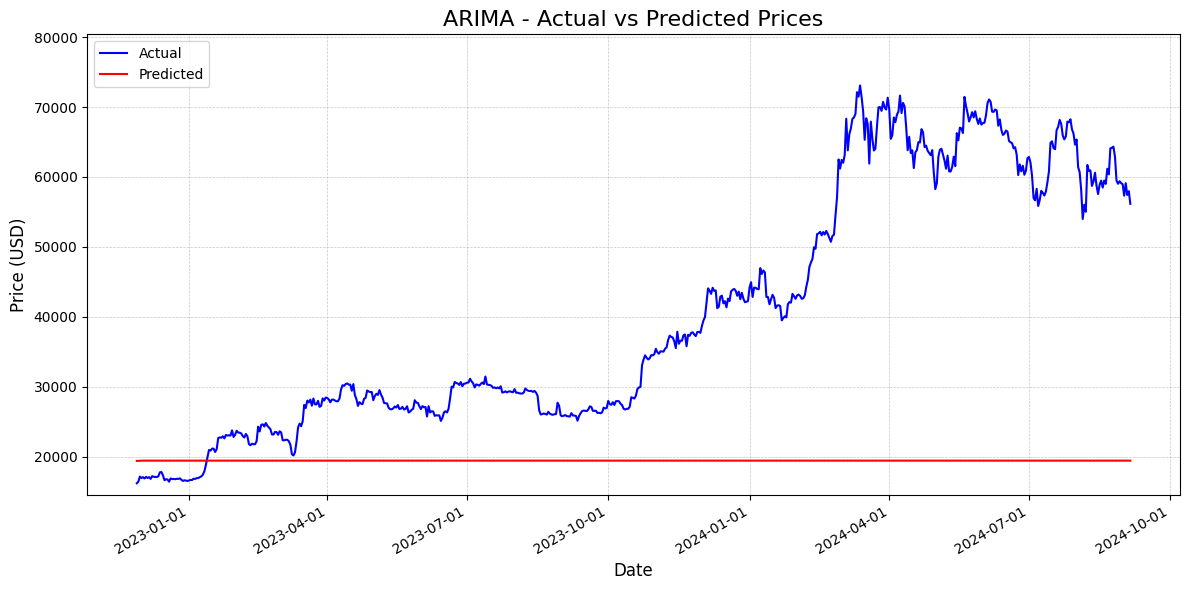

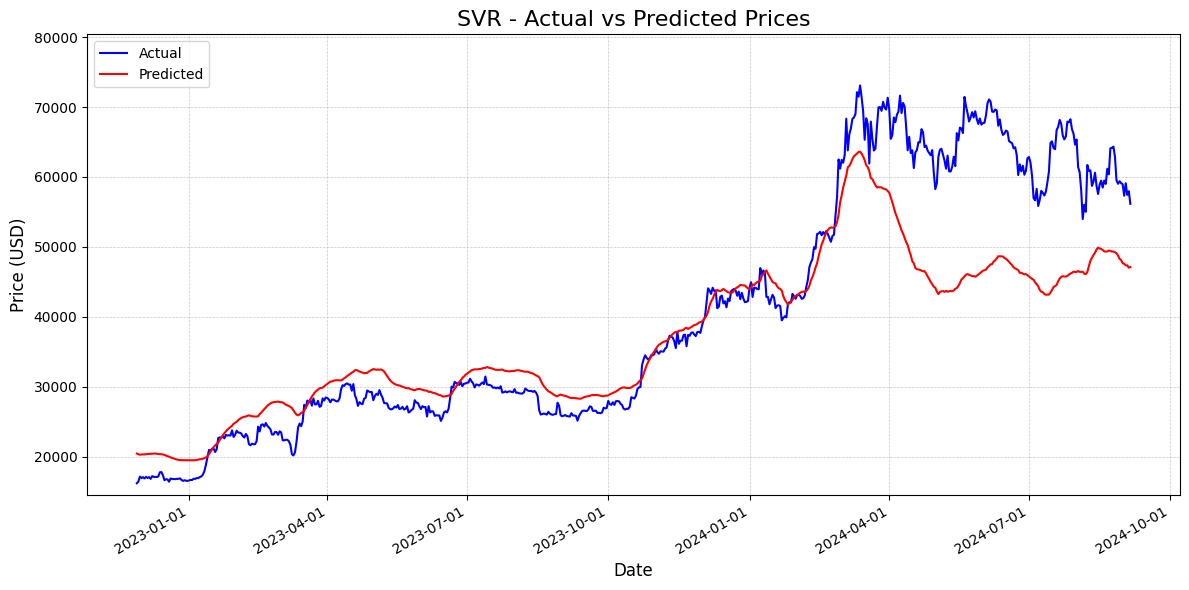

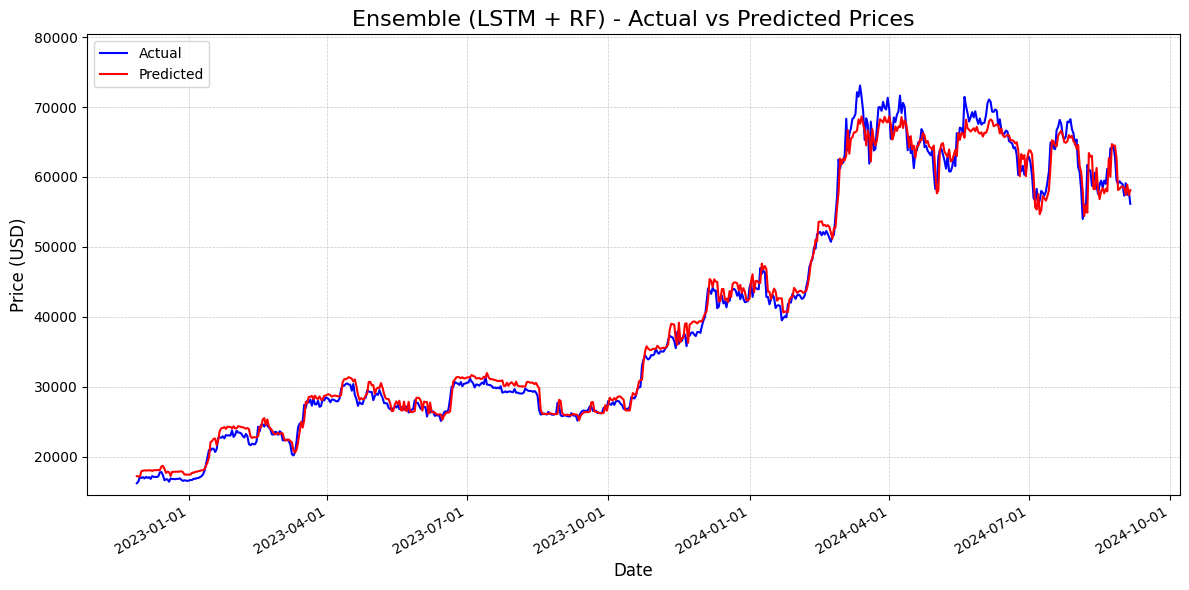

Actual price range: $16217.32 to $73083.50


In [ ]:
# Separate graphs for each model
test_dates = data.index[-len(y_test):]
actual_prices = scaler.inverse_transform(y_test)

for name, pred in models.items():
    plt.figure(figsize=(12, 6))
    plt.plot(test_dates, actual_prices, label='Actual', color='blue')
    plt.plot(test_dates, scaler.inverse_transform(pred), label='Predicted', color='red')
    plt.title(f'{name} - Actual vs Predicted Prices', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price (USD)', fontsize=12)
    plt.legend(loc='upper left', fontsize=10)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gcf().autofmt_xdate()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()

    # Set y-axis limits based on the actual data range
    y_min = min(np.min(actual_prices), np.min(scaler.inverse_transform(pred)))
    y_max = max(np.max(actual_prices), np.max(scaler.inverse_transform(pred)))
    plt.ylim(y_min * 0.9, y_max * 1.1)

    plt.show()

# Print actual price range for verification
print(f"Actual price range: ${np.min(actual_prices):.2f} to ${np.max(actual_prices):.2f}")

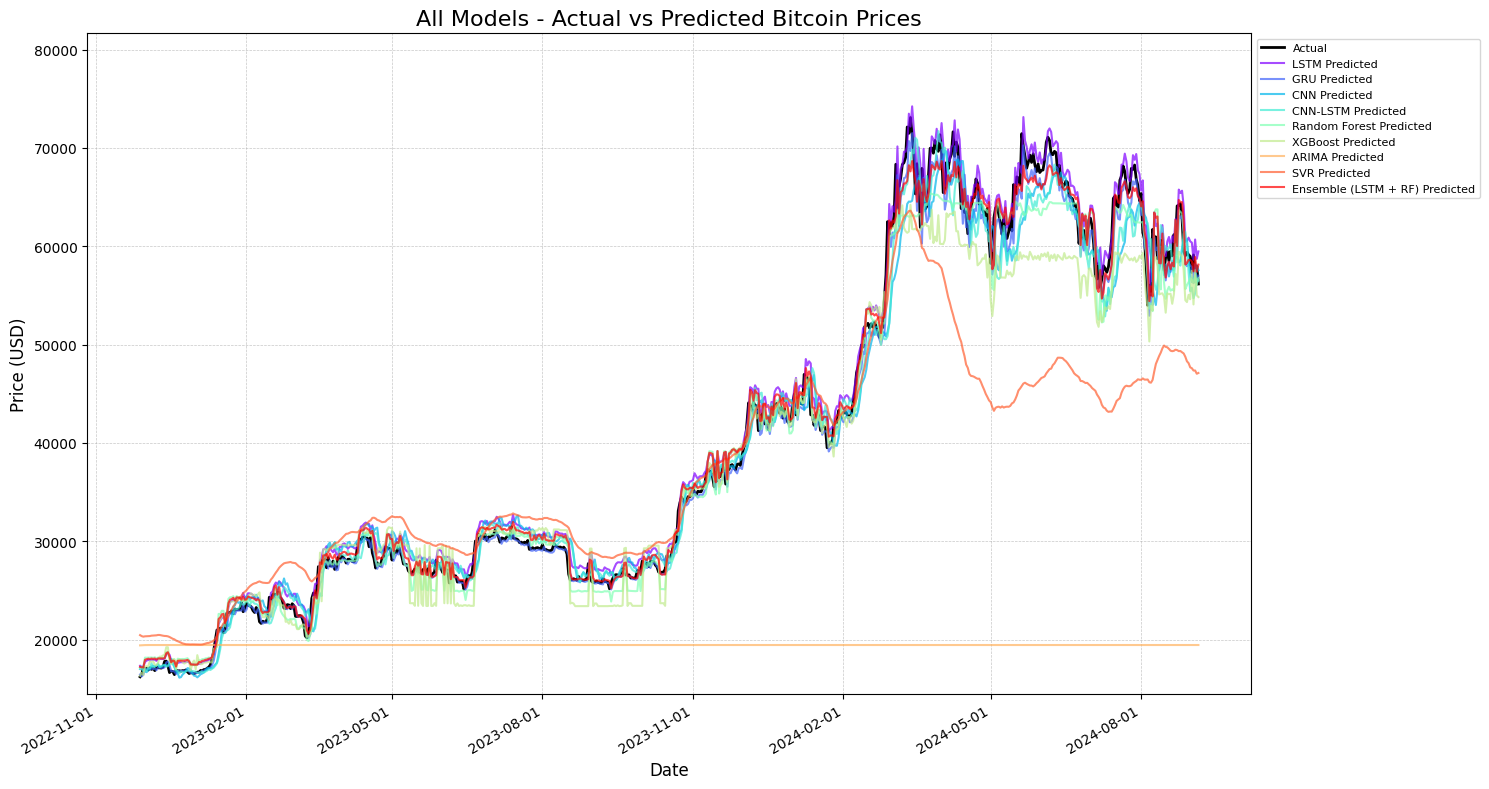

In [ ]:
# Set up the plot
plt.figure(figsize=(15, 8))

# Plot actual prices
test_dates = data.index[-len(y_test):]
actual_prices = scaler.inverse_transform(y_test)
plt.plot(test_dates, actual_prices, label='Actual', color='black', linewidth=2)

# Define a color palette for the models
colors = plt.cm.rainbow(np.linspace(0, 1, len(models)))

# Plot predicted prices for each model
models = {
    'LSTM': lstm_pred,
    'GRU': gru_pred,
    'CNN': cnn_pred,
    'CNN-LSTM': cnn_lstm_pred,
    'Random Forest': rf_pred.reshape(-1, 1),
    'XGBoost': xgb_pred.reshape(-1, 1),
    'ARIMA': arima_pred.reshape(-1, 1),
    'SVR': svr_pred.reshape(-1, 1),
    'Ensemble (LSTM + RF)': ensemble_pred
}
for (name, pred), color in zip(models.items(), colors):
    plt.plot(test_dates, scaler.inverse_transform(pred), label=f'{name} Predicted',
             color=color, alpha=0.7, linewidth=1.5)

# Customize the plot
plt.title('All Models - Actual vs Predicted Bitcoin Prices', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gcf().autofmt_xdate()
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Set y-axis limits
y_min = min(np.min(actual_prices), min([np.min(scaler.inverse_transform(pred)) for pred in models.values()]))
y_max = max(np.max(actual_prices), max([np.max(scaler.inverse_transform(pred)) for pred in models.values()]))
plt.ylim(y_min * 0.9, y_max * 1.1)

plt.tight_layout()
plt.show()

**Future Prediction:**

Uses each model to predict Bitcoin prices for the next 3 days.
Prints out these predictions

**Visualization:**

Creates a comprehensive plot showing: a. Historical Bitcoin prices b. Train/test split point c. Future predictions from all models Formats the plot for clear presentation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Predictions for next 3 days:
Date: 2024-09-06:
  LSTM: $55164.71
  GRU: $52802.72
  CNN: $53334.26
  CNN-LSTM: $52828.75
  Random Forest: $53650.42
  XGBoost: $53580.60
  SVR: $49049.96
  ARIMA: $19415.32
  Ensemble (LSTM + RF): $54407.57

Date: 2024-09-07:
  LSTM: $56772.02
  GRU: $51951.76
  CNN: $52489.97
  CNN-LSTM: $52649.16
  Random Forest: $53485.13
  XGBoost: $53151.11
  SVR: $48373.09
  ARIMA: $19426.96
  Ensemble (LSTM + RF): $55128.58

Date: 2024-09-08:
  LSTM: $58361.90
  GRU: $51151.07
  CNN: $51990.75
  CNN-LSTM: $52881.66


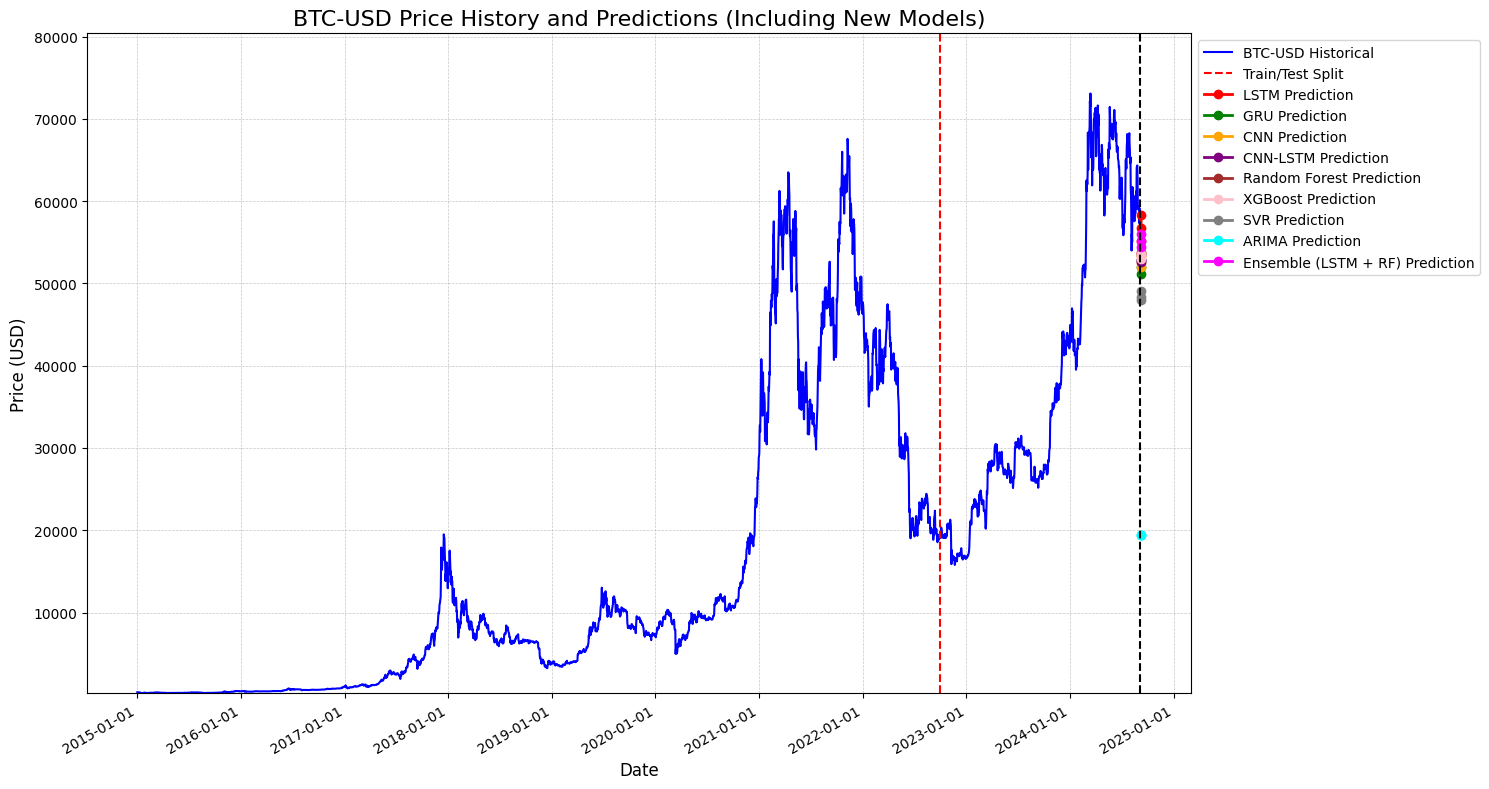

In [ ]:
# Predict next 3 days
last_sequence = X[-1]
future_pred = {}
future_dates = [data.index[-1] + timedelta(days=i+1) for i in range(3)]

def get_single_prediction(pred):
    if pred.ndim == 1:
        return pred[0]
    elif pred.ndim == 2:
        return pred[0, 0]
    else:
        raise ValueError(f"Unexpected prediction shape: {pred.shape}")

for name, model in [('LSTM', lstm_model), ('GRU', gru_model), ('CNN', cnn_model),
                    ('CNN-LSTM', cnn_lstm_model), ('Random Forest', rf_model),
                    ('XGBoost', xgb_model), ('SVR', svr_model)]:
    predictions = []
    current_sequence = last_sequence.copy()

    for _ in range(3):
        if name in ['LSTM', 'GRU', 'CNN', 'CNN-LSTM']:
            pred = model.predict(np.array([current_sequence]))
        else:
            pred = model.predict(current_sequence.reshape(1, -1))

        single_pred = get_single_prediction(pred)
        predictions.append(single_pred)

        # Update the sequence for the next prediction
        current_sequence = np.roll(current_sequence, -1)
        current_sequence[-1] = single_pred

    future_pred[name] = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

# ARIMA prediction
arima_model = ARIMA(scaled_train_data.flatten(), order=(5,1,0))
arima_result = arima_model.fit()
arima_future = arima_result.forecast(steps=3)
future_pred['ARIMA'] = scaler.inverse_transform(arima_future.reshape(-1, 1)).flatten()

# Ensemble prediction
lstm_predictions = future_pred['LSTM']
rf_predictions = future_pred['Random Forest']
future_pred['Ensemble (LSTM + RF)'] = (lstm_predictions + rf_predictions) / 2

print("\nPredictions for next 3 days:")
for i, date in enumerate(future_dates):
    print(f"Date: {date.strftime('%Y-%m-%d')}:")
    for model_name, predictions in future_pred.items():
        print(f"  {model_name}: ${predictions[i]:.2f}")
    print()  # Add a blank line between days

# Visualization
plt.figure(figsize=(15, 8))

# Plot full historical data
plt.plot(data.index, close_prices, label='BTC-USD Historical', color='blue')

# Plot train/test split
train_size = int(len(close_prices) * 0.8)
plt.axvline(x=data.index[train_size], color='red', linestyle='--', label='Train/Test Split')

# Plot predictions
colors = ['red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta', 'yellow']
for (name, pred), color in zip(future_pred.items(), colors):
    plt.plot(future_dates, pred, 'o-', label=f'{name} Prediction', color=color, linewidth=2)

plt.title('BTC-USD Price History and Predictions (Including New Models)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=10, bbox_to_anchor=(1, 1))

# Format x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gcf().autofmt_xdate()

# Add a vertical line to separate historical data from predictions
plt.axvline(x=data.index[-1], color='black', linestyle='--', label='Prediction Start')

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

# Adjust y-axis to show a bit more than the data range
y_min = min(min(close_prices), min([min(pred) for pred in future_pred.values()]))
y_max = max(max(close_prices), max([max(pred) for pred in future_pred.values()]))
plt.ylim(y_min * 0.9, y_max * 1.1)

plt.show()